# 🛡️ HireGuard AI
## Intelligent Recruitment Fraud Detection Using NLP & Machine Learning

### Final Data Science Project

---

## 📌 Project Overview

Online recruitment platforms have made job searching easier, but they have also created opportunities for fraudulent recruiters to publish fake job advertisements.

**HireGuard AI** is an end-to-end Data Science and Machine Learning system designed to identify potentially fraudulent job postings using Natural Language Processing (NLP) and machine learning.

The project analyzes recruitment advertisements, performs exploratory data analysis, processes textual information, trains multiple machine learning models, compares their performance, and selects the best model for real-time fraud detection.

The final trained model will be integrated with a **FastAPI backend** and an interactive **HTML, CSS, and JavaScript frontend**.

---

## 🎯 Project Objectives

- Perform comprehensive Exploratory Data Analysis (EDA)
- Clean and preprocess recruitment data
- Discover patterns associated with fraudulent job advertisements
- Apply Natural Language Processing to job-posting text
- Perform TF-IDF feature extraction
- Train multiple machine learning classification models
- Address class imbalance in the dataset
- Compare models using appropriate evaluation metrics
- Select and save the best-performing model
- Build a REST API using FastAPI
- Develop an interactive web interface for real-time predictions

---

## 🧠 Machine Learning Models

1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear Support Vector Machine (LinearSVC)
4. Random Forest

---

## 🛠️ Technology Stack

- **Programming:** Python
- **Data Analysis:** Pandas, NumPy
- **Visualization:** Matplotlib
- **Machine Learning:** Scikit-learn
- **NLP:** TF-IDF, NLTK
- **Backend:** FastAPI
- **Frontend:** HTML, CSS, JavaScript
- **Model Serialization:** Joblib
- **Development:** VS Code & Jupyter Notebook

In [1]:
# ============================================================
# HIREGUARD AI
# Intelligent Recruitment Fraud Detection
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Utilities
import os
import re
import warnings
import joblib

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print("=" * 60)
print("🛡️ HIREGUARD AI")
print("Environment initialized successfully!")
print("=" * 60)

🛡️ HIREGUARD AI
Environment initialized successfully!


# 1. 📂 Data Loading & Understanding

Before performing data preprocessing and machine learning, the dataset is loaded and examined to understand its dimensions, available features, data types, and target variable.

The target variable **`fraudulent`** represents whether a recruitment advertisement is legitimate or potentially fraudulent:

- **0 → Legitimate Job**
- **1 → Fraudulent Job**

In [2]:
# Load the raw recruitment dataset

DATA_PATH = "../data/raw/fake_job_postings.csv"

df = pd.read_csv(DATA_PATH)

print("✅ Dataset loaded successfully!")
print(f"📊 Total Job Postings : {df.shape[0]:,}")
print(f"📊 Total Features     : {df.shape[1]}")

df.head()

✅ Dataset loaded successfully!
📊 Total Job Postings : 17,880
📊 Total Features     : 18


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbreaking and award-winning cooking site. We support,...","<p>Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and...",<ul>\r\n<li>Experience with content management systems a major plus (any blogging counts!)</li>\...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Production Service.</h3>\r\n<p>90 Seconds is the worlds C...",<p>Organised - Focused - Vibrant - Awesome!<br><br>Do you have a passion for customer service? S...,<p><b>What we expect from you:</b></p>\r\n<p>Your key responsibility will be to communicate with...,<h3><b>What you will get from us</b></h3>\r\n<p>Through being part of the 90 Seconds team you wi...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workforce Solutions that meet the needs of companies acr...,"<p>Our client, located in Houston, is actively seeking an experienced Commissioning Machinery As...",<ul>\r\n<li>Implement pre-commissioning and commissioning procedures for rotary equipment.</li>\...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life through geography is at the heart of everything we ...,<p><b>THE COMPANY: ESRI – Environmental Systems Research Institute</b></p>\r\n<p>Our passion for...,"<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s or Master’s in GIS, business administration, or a r...","<p>Our culture is anything but corporate—we have a collaborative, creative environment; phone di...",f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human Capital Management Consulting firm headquartered i...,"<p><b>JOB TITLE:</b> Itemization Review Manager</p>\r\n<p><b>LOCATION:</b> Fort Worth, TX<b> ...",<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>RN license in the State of Texas</li>\r\n<li>Diplom...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


In [3]:
print("=" * 70)
print("HIREGUARD AI — DATASET OVERVIEW")
print("=" * 70)

print(f"\nDataset Shape: {df.shape}")

print("\n📋 Available Features:")
for number, column in enumerate(df.columns, start=1):
    print(f"{number:02}. {column}")

print("\n🔁 Duplicate Rows:")
print(df.duplicated().sum())

print("\n🎯 Target Values:")
print(df["fraudulent"].value_counts())

HIREGUARD AI — DATASET OVERVIEW

Dataset Shape: (17880, 18)

📋 Available Features:
01. title
02. location
03. department
04. salary_range
05. company_profile
06. description
07. requirements
08. benefits
09. telecommuting
10. has_company_logo
11. has_questions
12. employment_type
13. required_experience
14. required_education
15. industry
16. function
17. fraudulent
18. in_balanced_dataset

🔁 Duplicate Rows:
235

🎯 Target Values:
fraudulent
f    17014
t      866
Name: count, dtype: int64


In [4]:
# Analyze target-class distribution

class_counts = df["fraudulent"].value_counts().sort_index()

class_percentages = (
    df["fraudulent"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "Job Type": ["Legitimate", "Fraudulent"],
    "Count": [
        class_counts.get(0, 0),
        class_counts.get(1, 0)
    ],
    "Percentage (%)": [
        class_percentages.get(0, 0),
        class_percentages.get(1, 0)
    ]
})

target_summary["Percentage (%)"] = (
    target_summary["Percentage (%)"].round(2)
)

target_summary

,Job Type,Count,Percentage (%)
0,Legitimate,0,0
1,Fraudulent,0,0


# 2. 🧹 Data Cleaning & Preprocessing

Real-world datasets often contain missing values, duplicate records, irrelevant features, and inconsistent textual information.

In this section, the recruitment dataset is cleaned and prepared for Exploratory Data Analysis and Machine Learning.

In [5]:
# ============================================================
# DATA QUALITY ASSESSMENT
# ============================================================

print("=" * 70)
print("DATA QUALITY REPORT")
print("=" * 70)

print(f"\nTotal Rows       : {df.shape[0]:,}")
print(f"Total Columns    : {df.shape[1]}")
print(f"Duplicate Rows   : {df.duplicated().sum()}")

# Missing value analysis
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage.round(2)
})

missing_summary = (
    missing_summary[missing_summary["Missing Values"] > 0]
    .sort_values("Missing Percentage (%)", ascending=False)
)

missing_summary

DATA QUALITY REPORT

Total Rows       : 17,880
Total Columns    : 18
Duplicate Rows   : 235


,Missing Values,Missing Percentage (%)
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7196,40.25
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2689,15.04


## 2.1 Missing Value Analysis

Missing-value analysis helps identify features that require preprocessing before they can be used for statistical analysis or machine learning.

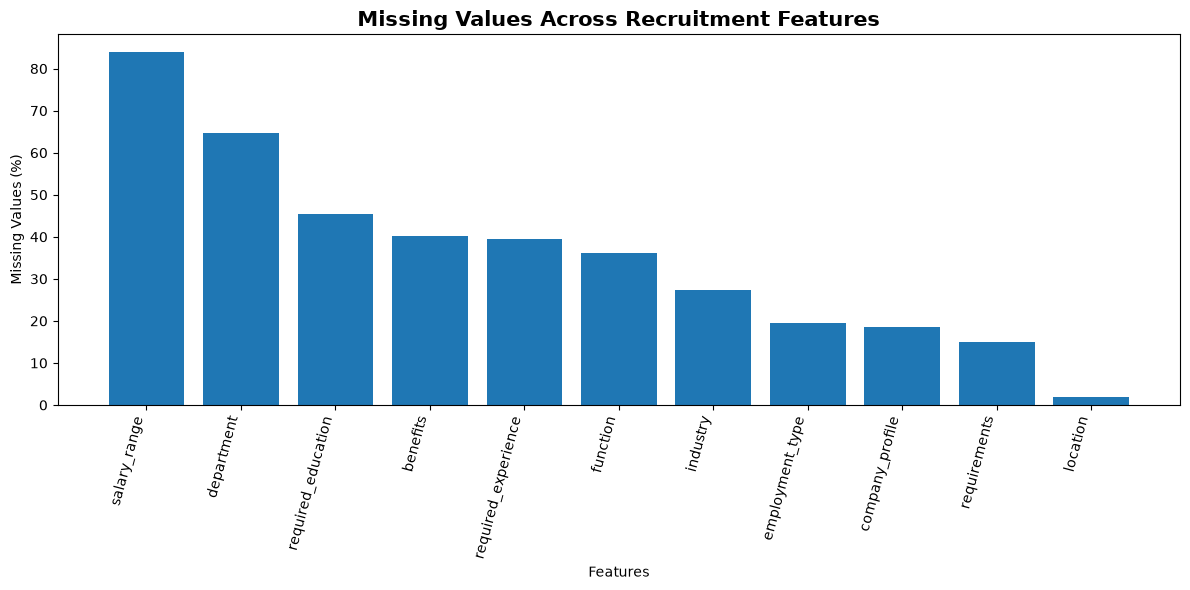

In [6]:
# Visualize missing-value percentages

plt.figure(figsize=(12, 6))

plt.bar(
    missing_summary.index,
    missing_summary["Missing Percentage (%)"]
)

plt.title(
    "Missing Values Across Recruitment Features",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Features")
plt.ylabel("Missing Values (%)")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()
plt.show()

In [7]:
# Create a copy of the original dataset

df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Cleaning copy created successfully.")

Original dataset shape: (17880, 18)
Cleaning copy created successfully.


In [8]:
# Remove identifier / dataset-construction columns

columns_to_remove = []

if "job_id" in df_clean.columns:
    columns_to_remove.append("job_id")

if "in_balanced_dataset" in df_clean.columns:
    columns_to_remove.append("in_balanced_dataset")

df_clean.drop(
    columns=columns_to_remove,
    inplace=True
)

print("Removed columns:", columns_to_remove)

print("\nRemaining dataset shape:")
print(df_clean.shape)

Removed columns: ['in_balanced_dataset']

Remaining dataset shape:
(17880, 17)


In [9]:
# Remove duplicate records

duplicates_before = df_clean.duplicated().sum()

df_clean.drop_duplicates(inplace=True)

duplicates_after = df_clean.duplicated().sum()

print(f"Duplicates before cleaning : {duplicates_before}")
print(f"Duplicates after cleaning  : {duplicates_after}")
print(f"Current dataset size       : {df_clean.shape}")

Duplicates before cleaning : 248
Duplicates after cleaning  : 0
Current dataset size       : (17632, 17)


In [10]:
# Text-based features used in recruitment advertisements

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for column in text_columns:
    if column in df_clean.columns:
        df_clean[column] = df_clean[column].fillna("")

print("✅ Missing textual values replaced successfully.")

✅ Missing textual values replaced successfully.


In [11]:
categorical_columns = [
    "location",
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

for column in categorical_columns:
    if column in df_clean.columns:
        df_clean[column] = df_clean[column].fillna("Unknown")

print("✅ Missing categorical values handled successfully.")

✅ Missing categorical values handled successfully.


## 2.2 NLP Feature Construction

A recruitment advertisement contains useful textual information across multiple fields rather than only its description.

To provide the NLP model with richer context, the job title, company profile, job description, requirements, and benefits are combined into a single feature called **combined_text**.

In [12]:
# Combine important textual features

df_clean["combined_text"] = (
    df_clean["title"].astype(str) + " " +
    df_clean["company_profile"].astype(str) + " " +
    df_clean["description"].astype(str) + " " +
    df_clean["requirements"].astype(str) + " " +
    df_clean["benefits"].astype(str)
)

print("✅ Combined NLP text feature created!")

df_clean[
    ["title", "combined_text", "fraudulent"]
].head()

✅ Combined NLP text feature created!


,title,combined_text,fraudulent
0,Marketing Intern,"Marketing Intern <h3>We're Food52, and we've created a groundbreaking and award-winning cooking ...",f
1,Customer Service - Cloud Video Production,"Customer Service - Cloud Video Production <h3>90 Seconds, the worlds Cloud Video Production Serv...",f
2,Commissioning Machinery Assistant (CMA),Commissioning Machinery Assistant (CMA) <h3></h3>\r\n<p>Valor Services provides Workforce Soluti...,f
3,Account Executive - Washington DC,Account Executive - Washington DC <p>Our passion for improving quality of life through geography...,f
4,Bill Review Manager,Bill Review Manager <p>SpotSource Solutions LLC is a Global Human Capital Management Consulting ...,f


In [13]:
# Feature engineering for EDA

df_clean["text_length"] = (
    df_clean["combined_text"]
    .astype(str)
    .str.len()
)

df_clean["word_count"] = (
    df_clean["combined_text"]
    .astype(str)
    .str.split()
    .str.len()
)

print("Text Length Statistics:")
display(df_clean["text_length"].describe())

print("\nWord Count Statistics:")
display(df_clean["word_count"].describe())

Text Length Statistics:


count    17632.000000
mean      3165.899274
std       3107.000947
min         33.000000
25%       1845.000000
50%       2869.000000
75%       3951.000000
max      97014.000000
Name: text_length, dtype: float64


Word Count Statistics:


count    17632.000000
mean       409.470168
std        289.667589
min          4.000000
25%        245.750000
50%        375.000000
75%        526.000000
max       7018.000000
Name: word_count, dtype: float64

In [14]:
# Save processed dataset

PROCESSED_PATH = "../data/processed/cleaned_job_postings.csv"

df_clean.to_csv(
    PROCESSED_PATH,
    index=False
)

print("✅ Cleaned dataset saved successfully!")
print(f"Location: {PROCESSED_PATH}")
print(f"Final Shape: {df_clean.shape}")

✅ Cleaned dataset saved successfully!
Location: ../data/processed/cleaned_job_postings.csv
Final Shape: (17632, 20)


# 3. 📊 Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the characteristics of legitimate and fraudulent recruitment advertisements and identify patterns that may be useful for fraud detection.


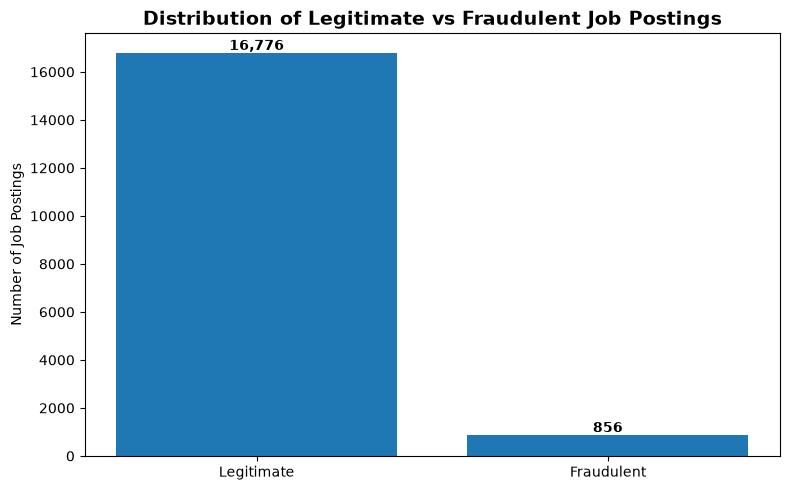

In [15]:
# Target class distribution

class_counts = df_clean["fraudulent"].value_counts().sort_index()

labels = ["Legitimate", "Fraudulent"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    class_counts.values
)

plt.title(
    "Distribution of Legitimate vs Fraudulent Job Postings",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Number of Job Postings")

for bar, value in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# CONVERT TARGET VARIABLE TO NUMERIC FORMAT
# ============================================================

print("Target values before conversion:")
print(df_clean["fraudulent"].value_counts())

# Convert boolean/string target values into binary labels
df_clean["fraudulent"] = (
    df_clean["fraudulent"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "f": 0,
        "false": 0,
        "0": 0,
        "t": 1,
        "true": 1,
        "1": 1
    })
)

# Verify conversion
print("\nTarget values after conversion:")
print(df_clean["fraudulent"].value_counts())

print("\nTarget datatype:")
print(df_clean["fraudulent"].dtype)

Target values before conversion:
fraudulent
f    16776
t      856
Name: count, dtype: int64

Target values after conversion:
fraudulent
0    16776
1      856
Name: count, dtype: int64

Target datatype:
int64


In [17]:
# Check whether any target values failed to convert

missing_target = df_clean["fraudulent"].isna().sum()

print(f"Invalid/Missing target values: {missing_target}")

if missing_target == 0:
    df_clean["fraudulent"] = df_clean["fraudulent"].astype(int)
    print("✅ Target variable successfully converted to binary format.")
else:
    print("⚠️ Some target values require investigation.")

Invalid/Missing target values: 0
✅ Target variable successfully converted to binary format.


In [18]:
total_jobs = len(df_clean)

fraud_jobs = int(df_clean["fraudulent"].sum())
legitimate_jobs = total_jobs - fraud_jobs

fraud_rate = (fraud_jobs / total_jobs) * 100

print("=" * 55)
print("HIREGUARD AI — FRAUD ANALYSIS")
print("=" * 55)

print(f"Total Job Postings : {total_jobs:,}")
print(f"Legitimate Jobs    : {legitimate_jobs:,}")
print(f"Fraudulent Jobs    : {fraud_jobs:,}")
print(f"Fraud Rate         : {fraud_rate:.2f}%")

HIREGUARD AI — FRAUD ANALYSIS
Total Job Postings : 17,632
Legitimate Jobs    : 16,776
Fraudulent Jobs    : 856
Fraud Rate         : 4.85%


### 🔎 Observation

The target variable is highly imbalanced, with legitimate advertisements representing the overwhelming majority of the dataset.

This creates an important machine-learning challenge. A classifier could achieve high accuracy simply by predicting most advertisements as legitimate.

Therefore, **accuracy alone will not be considered sufficient for model evaluation**. Particular attention will be given to:

- Precision
- Recall
- F1-Score
- Confusion Matrix
- ROC-AUC
- Precision-Recall performance

Recall for the fraudulent class is especially important because false negatives represent fraudulent advertisements that the system fails to detect.

## 3.1 🔍 Fraud Pattern Analysis

To understand what characteristics may distinguish fraudulent advertisements from legitimate ones, several recruitment attributes are analyzed against the target variable.

In [19]:
binary_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

for column in binary_columns:
    if column in df_clean.columns:
        print(f"\n{column}:")
        print(df_clean[column].value_counts(dropna=False))
        print("-" * 50)


telecommuting:
telecommuting
f    16876
t      756
Name: count, dtype: int64
--------------------------------------------------

has_company_logo:
has_company_logo
t    14001
f     3631
Name: count, dtype: int64
--------------------------------------------------

has_questions:
has_questions
f    8962
t    8670
Name: count, dtype: int64
--------------------------------------------------


In [20]:
# Standardize binary/boolean columns

binary_mapping = {
    "t": 1,
    "true": 1,
    "1": 1,
    "yes": 1,

    "f": 0,
    "false": 0,
    "0": 0,
    "no": 0
}

for column in binary_columns:
    if column in df_clean.columns:

        converted = (
            df_clean[column]
            .astype(str)
            .str.strip()
            .str.lower()
            .map(binary_mapping)
        )

        # Only replace if conversion was successful
        if converted.notna().sum() > 0:
            df_clean[column] = converted

print("✅ Binary features standardized.")

for column in binary_columns:
    if column in df_clean.columns:
        print(f"\n{column}:")
        print(df_clean[column].value_counts(dropna=False))

✅ Binary features standardized.

telecommuting:
telecommuting
0    16876
1      756
Name: count, dtype: int64

has_company_logo:
has_company_logo
1    14001
0     3631
Name: count, dtype: int64

has_questions:
has_questions
0    8962
1    8670
Name: count, dtype: int64


In [21]:
logo_analysis = pd.crosstab(
    df_clean["has_company_logo"],
    df_clean["fraudulent"],
    normalize="index"
) * 100

logo_analysis.columns = ["Legitimate (%)", "Fraudulent (%)"]

display(logo_analysis.round(2))

,Legitimate (%),Fraudulent (%)
has_company_logo,,
0,84.19,15.81
1,97.99,2.01


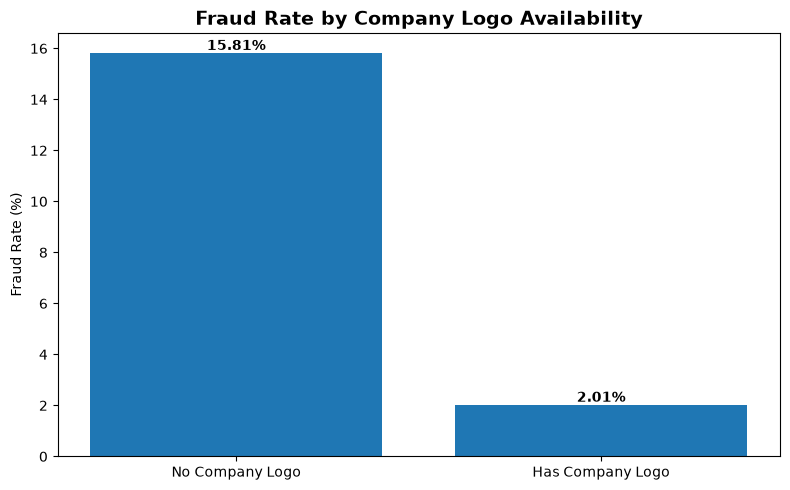

In [22]:
fraud_by_logo = (
    df_clean
    .groupby("has_company_logo")["fraudulent"]
    .mean() * 100
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["No Company Logo", "Has Company Logo"],
    fraud_by_logo.values
)

plt.title(
    "Fraud Rate by Company Logo Availability",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Fraud Rate (%)")

for bar, value in zip(bars, fraud_by_logo.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [23]:
employment_analysis = (
    df_clean
    .groupby("employment_type")
    .agg(
        Total_Jobs=("fraudulent", "size"),
        Fraudulent_Jobs=("fraudulent", "sum"),
        Fraud_Rate=("fraudulent", "mean")
    )
    .reset_index()
)

employment_analysis["Fraud_Rate"] *= 100

employment_analysis = employment_analysis.sort_values(
    "Total_Jobs",
    ascending=False
)

display(employment_analysis.round(2))

,employment_type,Total_Jobs,Fraudulent_Jobs,Fraud_Rate
1,Full-time,11450,487,4.25
5,Unknown,3433,236,6.87
0,Contract,1514,43,2.84
3,Part-time,773,73,9.44
4,Temporary,237,2,0.84
2,Other,225,15,6.67


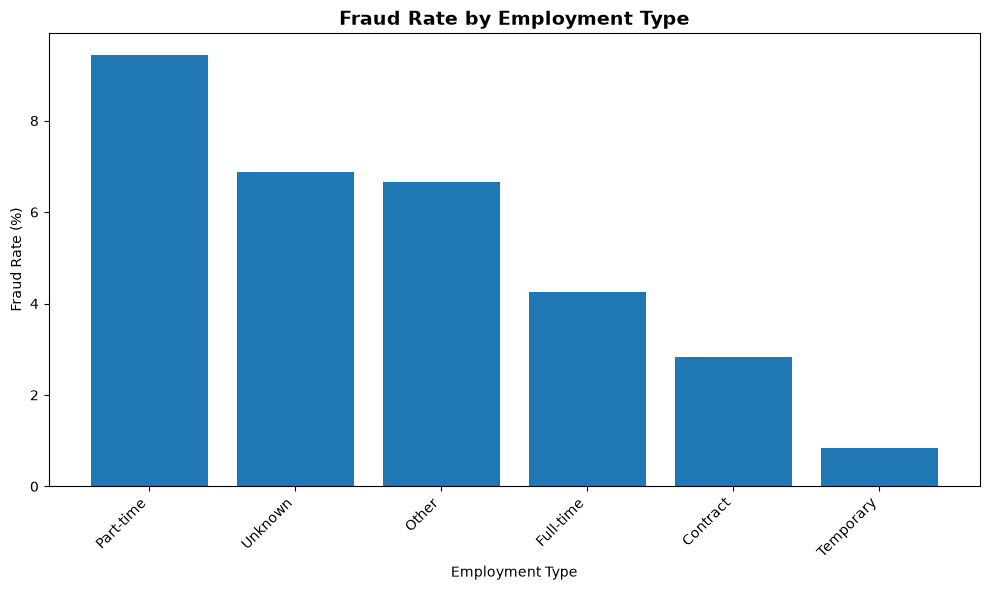

In [24]:
employment_plot = employment_analysis[
    employment_analysis["Total_Jobs"] >= 20
].sort_values("Fraud_Rate", ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(
    employment_plot["employment_type"],
    employment_plot["Fraud_Rate"]
)

plt.title(
    "Fraud Rate by Employment Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Employment Type")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [25]:
experience_analysis = (
    df_clean
    .groupby("required_experience")
    .agg(
        Total_Jobs=("fraudulent", "size"),
        Fraudulent_Jobs=("fraudulent", "sum"),
        Fraud_Rate=("fraudulent", "mean")
    )
    .reset_index()
)

experience_analysis["Fraud_Rate"] *= 100

experience_analysis = experience_analysis.sort_values(
    "Fraud_Rate",
    ascending=False
)

display(experience_analysis.round(2))

,required_experience,Total_Jobs,Fraudulent_Jobs,Fraud_Rate
3,Executive,140,10,7.14
2,Entry level,2643,177,6.70
7,Unknown,6972,427,6.12
6,Not Applicable,1071,60,5.60
1,Director,385,17,4.42
5,Mid-Senior level,3774,113,2.99
4,Internship,373,10,2.68
0,Associate,2274,42,1.85


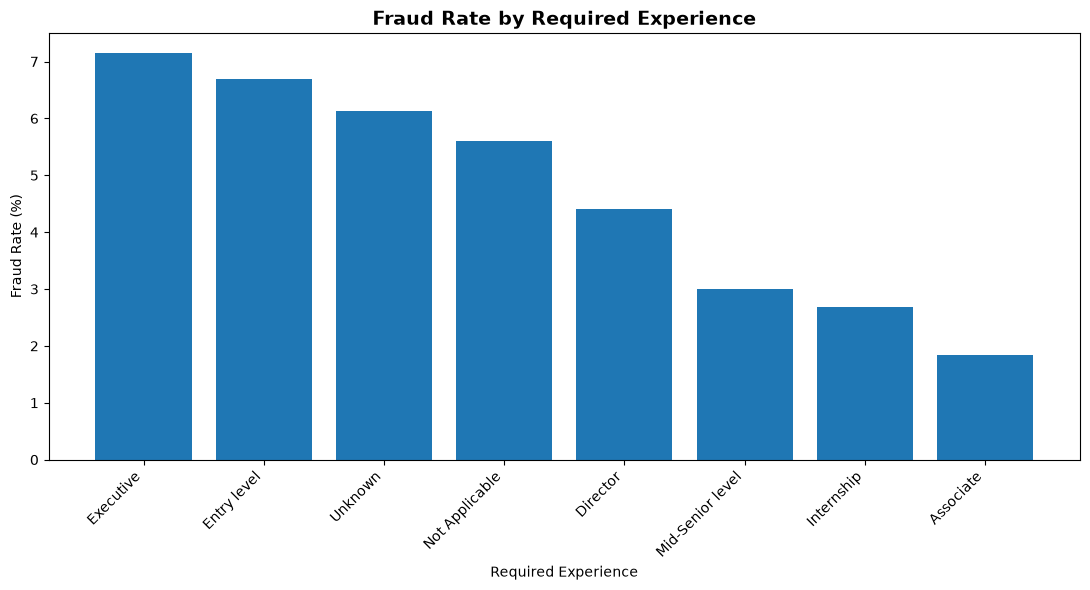

In [26]:
experience_plot = experience_analysis[
    experience_analysis["Total_Jobs"] >= 20
]

plt.figure(figsize=(11, 6))

plt.bar(
    experience_plot["required_experience"],
    experience_plot["Fraud_Rate"]
)

plt.title(
    "Fraud Rate by Required Experience",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Required Experience")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [27]:
education_analysis = (
    df_clean
    .groupby("required_education")
    .agg(
        Total_Jobs=("fraudulent", "size"),
        Fraudulent_Jobs=("fraudulent", "sum"),
        Fraud_Rate=("fraudulent", "mean")
    )
    .reset_index()
)

education_analysis["Fraud_Rate"] *= 100

education_analysis = education_analysis.sort_values(
    "Fraud_Rate",
    ascending=False
)

display(education_analysis.round(2))

,required_education,Total_Jobs,Fraudulent_Jobs,Fraud_Rate
8,Some High School Coursework,27,20,74.07
2,Certification,165,19,11.52
4,High School or equivalent,1994,168,8.43
5,Master's Degree,416,31,7.45
9,Unknown,8024,444,5.53
6,Professional,73,4,5.48
10,Unspecified,1374,61,4.44
3,Doctorate,26,1,3.85
7,Some College Coursework Completed,100,3,3.00
0,Associate Degree,264,6,2.27


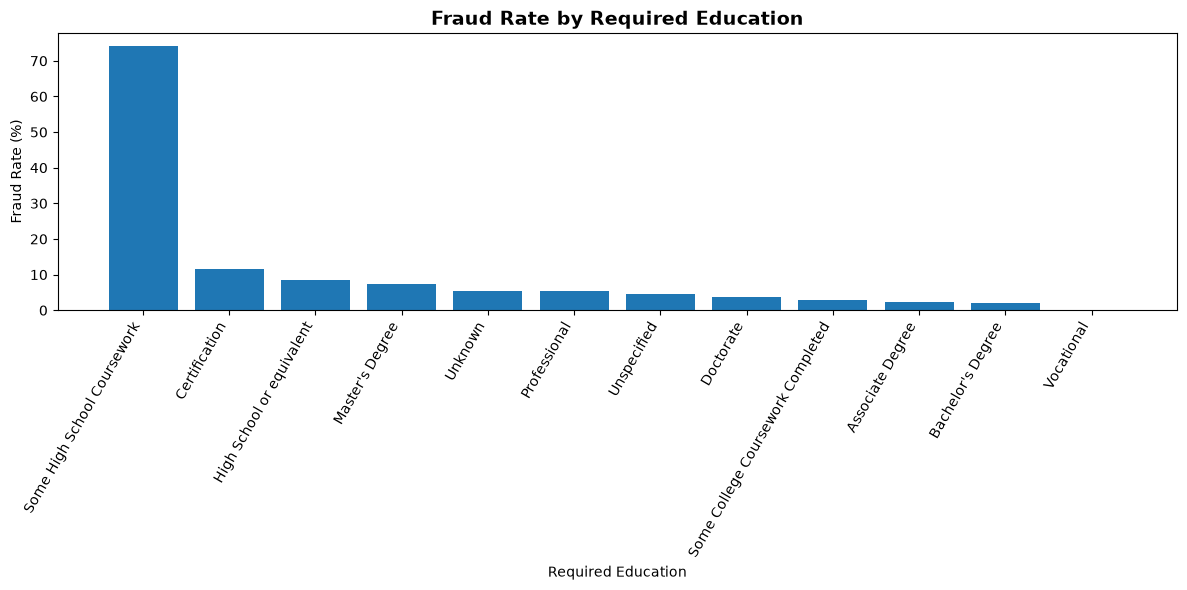

In [28]:
education_plot = education_analysis[
    education_analysis["Total_Jobs"] >= 20
]

plt.figure(figsize=(12, 6))

plt.bar(
    education_plot["required_education"],
    education_plot["Fraud_Rate"]
)

plt.title(
    "Fraud Rate by Required Education",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Required Education")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

In [29]:
text_stats = (
    df_clean
    .groupby("fraudulent")[["text_length", "word_count"]]
    .agg(["mean", "median"])
)

text_stats.index = ["Legitimate", "Fraudulent"]

display(text_stats.round(2))

text_length         word_count       
                  mean  median       mean median
Legitimate     3197.09  2915.0     414.96  381.0
Fraudulent     2554.67  1976.5     301.91  240.0

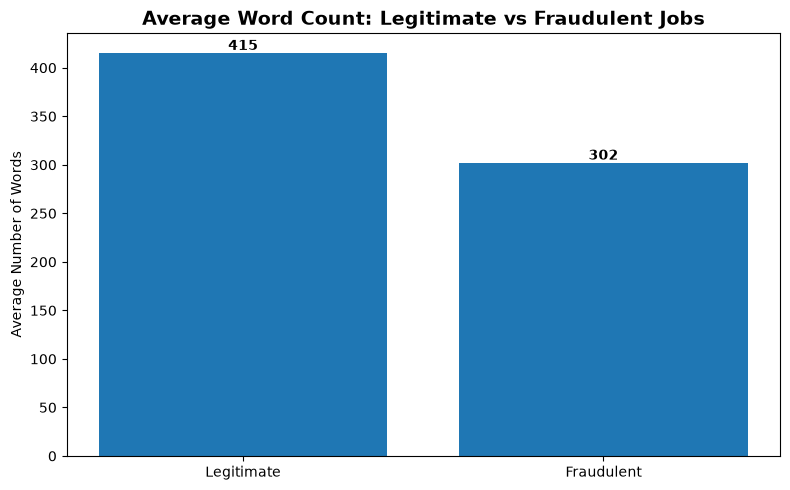

In [30]:
avg_word_count = (
    df_clean
    .groupby("fraudulent")["word_count"]
    .mean()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["Legitimate", "Fraudulent"],
    avg_word_count.values
)

plt.title(
    "Average Word Count: Legitimate vs Fraudulent Jobs",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Average Number of Words")

for bar, value in zip(bars, avg_word_count.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.0f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## 3.2 🧠 Text Analysis

Since recruitment advertisements contain large amounts of unstructured textual information, Natural Language Processing techniques are used to analyze their vocabulary.

Before analyzing word frequencies, the text is normalized by converting it to lowercase, removing URLs, HTML tags, special characters, numbers, and unnecessary whitespace.

In [31]:
def clean_text(text):
    """
    Clean recruitment advertisement text
    for exploratory NLP analysis.
    """

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep alphabetic characters only
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove excessive whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [32]:
sample_text = """
URGENT!!! Earn $5000/week!!!
Apply at https://fake-example.com <br>
No Experience Required!!!
"""

print("Original:")
print(sample_text)

print("\nCleaned:")
print(clean_text(sample_text))

Original:

URGENT!!! Earn $5000/week!!!
Apply at https://fake-example.com <br>
No Experience Required!!!


Cleaned:
urgent earn week apply at no experience required


In [33]:
df_clean["clean_text"] = (
    df_clean["combined_text"]
    .apply(clean_text)
)

print("✅ NLP text cleaning completed.")

display(
    df_clean[
        ["combined_text", "clean_text", "fraudulent"]
    ].head(3)
)

✅ NLP text cleaning completed.


,combined_text,clean_text,fraudulent
0,"Marketing Intern <h3>We're Food52, and we've created a groundbreaking and award-winning cooking ...",marketing intern we re food and we ve created a groundbreaking and award winning cooking site we...,0
1,"Customer Service - Cloud Video Production <h3>90 Seconds, the worlds Cloud Video Production Serv...",customer service cloud video production seconds the worlds cloud video production service second...,0
2,Commissioning Machinery Assistant (CMA) <h3></h3>\r\n<p>Valor Services provides Workforce Soluti...,commissioning machinery assistant cma valor services provides workforce solutions that meet the ...,0


In [34]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

In [35]:
def get_common_words(text_series, n=20):
    # Import inside function so Counter is always available
    from collections import Counter
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

    stop_words = set(ENGLISH_STOP_WORDS)

    all_words = []

    for text in text_series:

        # Skip missing values
        if pd.isna(text):
            continue

        words = str(text).split()

        words = [
            word
            for word in words
            if word not in stop_words and len(word) > 2
        ]

        all_words.extend(words)

    word_counts = Counter(all_words)

    return word_counts.most_common(n)


print("✅ Common-word analysis function created successfully!")

✅ Common-word analysis function created successfully!


In [36]:
fraud_text = df_clean.loc[
    df_clean["fraudulent"] == 1,
    "clean_text"
]

fraud_common_words = get_common_words(
    fraud_text,
    n=20
)

fraud_words_df = pd.DataFrame(
    fraud_common_words,
    columns=["Word", "Frequency"]
)

print("🚨 Top 20 Words in Fraudulent Job Advertisements")

fraud_words_df

🚨 Top 20 Words in Fraudulent Job Advertisements


,Word,Frequency
0,work,1789
1,experience,1729
2,skills,1298
3,amp,1133
4,company,909
5,team,896
6,time,853
7,ability,751
8,service,750
9,management,746


In [37]:
from collections import Counter

test = Counter(["job", "job", "work", "company"])

print(test)

Counter({'job': 2, 'work': 1, 'company': 1})


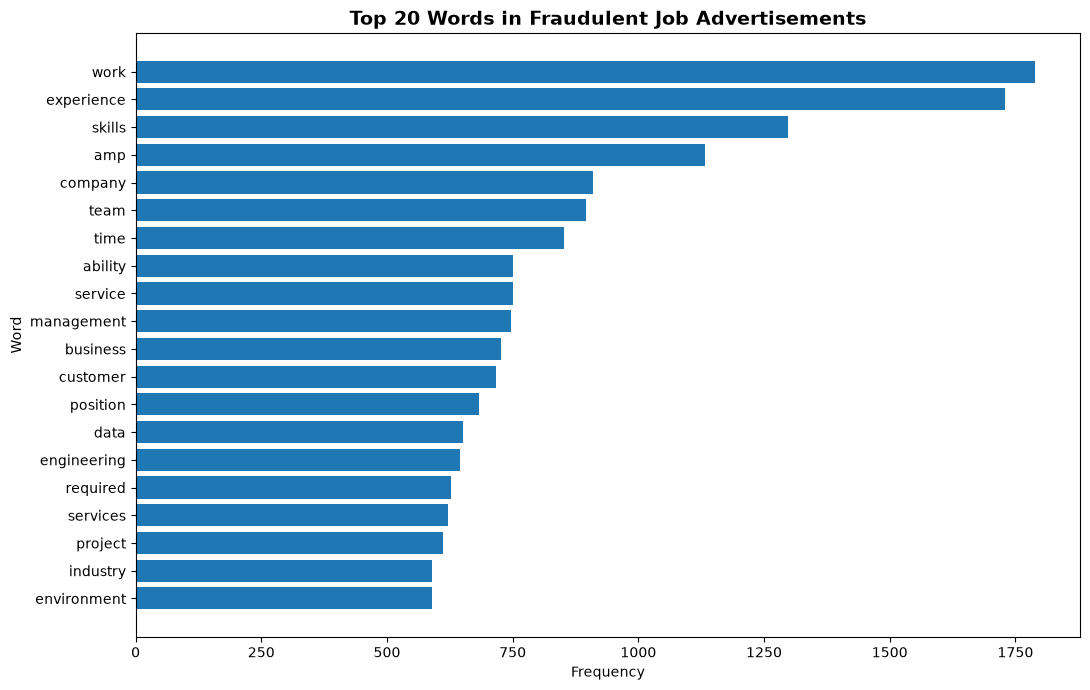

In [38]:
plt.figure(figsize=(11, 7))

plt.barh(
    fraud_words_df["Word"][::-1],
    fraud_words_df["Frequency"][::-1]
)

plt.title(
    "Top 20 Words in Fraudulent Job Advertisements",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

In [39]:
legitimate_text = df_clean.loc[
    df_clean["fraudulent"] == 0,
    "clean_text"
]

legitimate_common_words = get_common_words(
    legitimate_text,
    20
)

legitimate_words_df = pd.DataFrame(
    legitimate_common_words,
    columns=["Word", "Frequency"]
)

legitimate_words_df

,Word,Frequency
0,experience,45427
1,work,37182
2,team,34430
3,false,33105
4,skills,23370
5,company,22211
6,business,21749
7,new,17357
8,customer,17096
9,management,17019


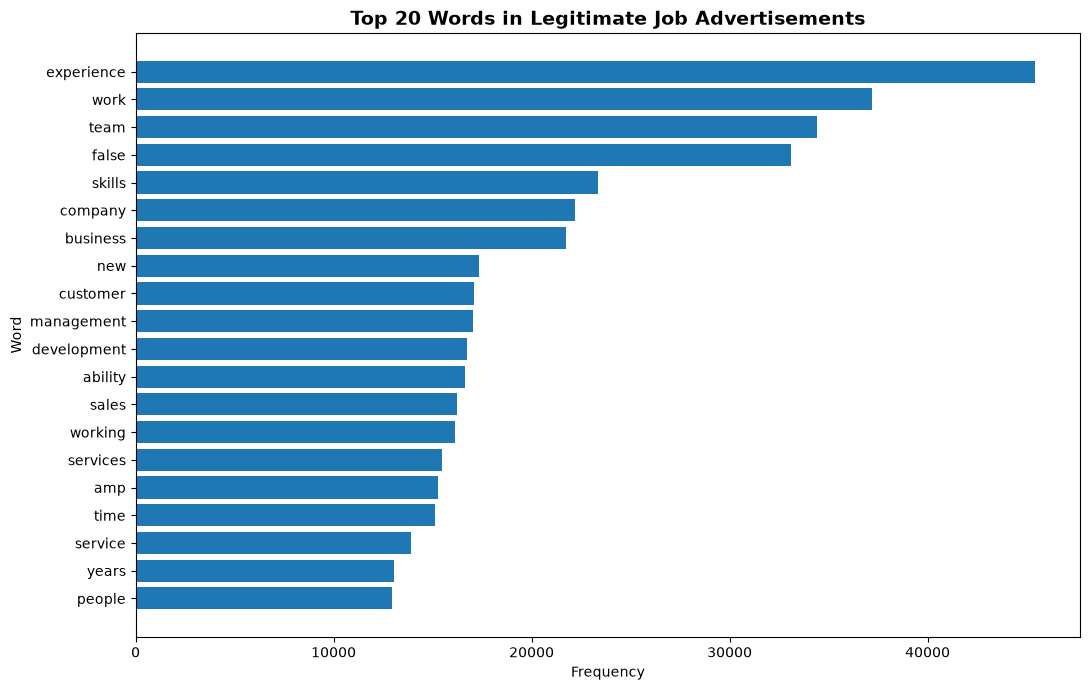

In [40]:
plt.figure(figsize=(11, 7))

plt.barh(
    legitimate_words_df["Word"][::-1],
    legitimate_words_df["Frequency"][::-1]
)

plt.title(
    "Top 20 Words in Legitimate Job Advertisements",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

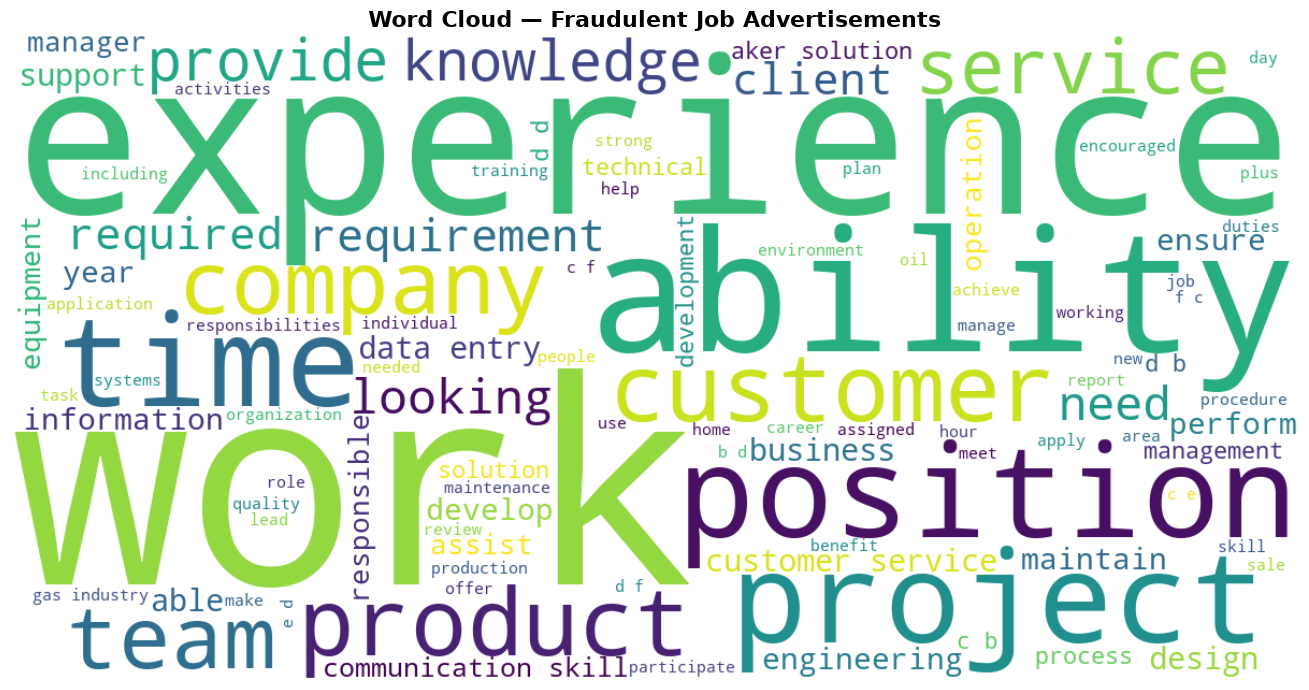

In [41]:
from wordcloud import WordCloud

fraud_text_combined = " ".join(fraud_text)

fraud_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stop_words,
    max_words=100
).generate(fraud_text_combined)

plt.figure(figsize=(14, 7))

plt.imshow(
    fraud_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Word Cloud — Fraudulent Job Advertisements",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [42]:
df_clean.to_csv(
    "../data/processed/cleaned_job_postings.csv",
    index=False
)

print("✅ Final processed dataset saved.")
print(f"Rows    : {df_clean.shape[0]:,}")
print(f"Columns : {df_clean.shape[1]}")

✅ Final processed dataset saved.
Rows    : 17,632
Columns : 21


# 4. 🤖 Machine Learning Model Development

The cleaned recruitment advertisements are now used to train machine learning models for fraudulent job detection.

The dataset is split into training and testing sets using stratified sampling so that the proportion of legitimate and fraudulent jobs remains consistent in both sets.

In [43]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X = df_clean["clean_text"]
y = df_clean["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("✅ Train-test split completed successfully!")

print(f"\nTraining Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

✅ Train-test split completed successfully!

Training Samples : 14,105
Testing Samples  : 3,527

Training Target Distribution:
fraudulent
0    13420
1      685
Name: count, dtype: int64

Testing Target Distribution:
fraudulent
0    3356
1     171
Name: count, dtype: int64


## 4.1 🔤 TF-IDF Feature Extraction

TF-IDF converts the cleaned recruitment text into numerical vectors that can be processed by machine learning algorithms.

Both single words and two-word phrases are considered using unigrams and bigrams.

To avoid data leakage, the vectorizer is fitted only on the training data and then applied to the testing data.

In [44]:
# ============================================================
# TF-IDF FEATURE EXTRACTION
# ============================================================

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words="english",
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("✅ TF-IDF vectorization completed!")

print(f"\nTraining Matrix : {X_train_tfidf.shape}")
print(f"Testing Matrix  : {X_test_tfidf.shape}")
print(f"Vocabulary Size : {len(tfidf.vocabulary_):,}")

✅ TF-IDF vectorization completed!

Training Matrix : (14105, 15000)
Testing Matrix  : (3527, 15000)
Vocabulary Size : 15,000


## 4.2 📈 Logistic Regression

Logistic Regression is used as the baseline classifier.

Because fraudulent job postings represent only a small minority of the dataset, balanced class weighting is applied to reduce bias toward legitimate advertisements.

In [45]:
# ============================================================
# MODEL 1 — LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

print("✅ Logistic Regression trained successfully!")

✅ Logistic Regression trained successfully!


In [46]:
logistic_predictions = logistic_model.predict(X_test_tfidf)

log_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

log_precision = precision_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

log_recall = recall_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

log_f1 = f1_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"Accuracy  : {log_accuracy:.4f}")
print(f"Precision : {log_precision:.4f}")
print(f"Recall    : {log_recall:.4f}")
print(f"F1-Score  : {log_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "Legitimate",
            "Fraudulent"
        ],
        zero_division=0
    )
)

LOGISTIC REGRESSION RESULTS
Accuracy  : 0.9759
Precision : 0.7087
Recall    : 0.8538
F1-Score  : 0.7745

Classification Report:

              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99      3356
  Fraudulent       0.71      0.85      0.77       171

    accuracy                           0.98      3527
   macro avg       0.85      0.92      0.88      3527
weighted avg       0.98      0.98      0.98      3527



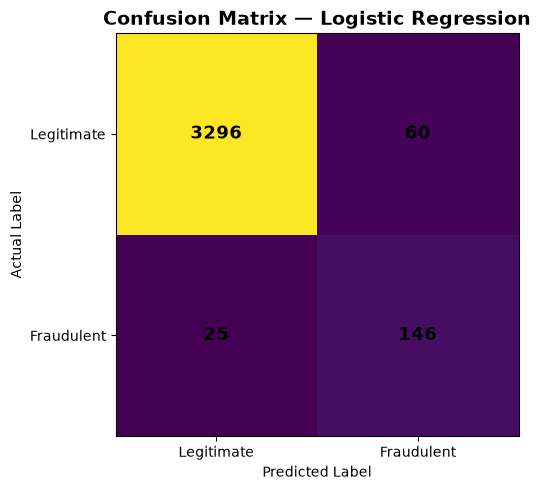

In [47]:
# ============================================================
# LOGISTIC REGRESSION — CONFUSION MATRIX
# ============================================================

log_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(6, 5))

plt.imshow(log_cm)

plt.title(
    "Confusion Matrix — Logistic Regression",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            log_cm[i, j],
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

## 4.3 🧠 Multinomial Naive Bayes

Multinomial Naive Bayes is a probabilistic machine learning algorithm commonly used for text-classification problems.

It provides an efficient benchmark for determining whether word-frequency patterns extracted through TF-IDF are sufficient to distinguish fraudulent recruitment advertisements from legitimate ones.

In [48]:
# ============================================================
# MODEL 2 — MULTINOMIAL NAIVE BAYES
# ============================================================

nb_model = MultinomialNB(
    alpha=0.5
)

nb_model.fit(
    X_train_tfidf,
    y_train
)

print("✅ Multinomial Naive Bayes trained successfully!")

✅ Multinomial Naive Bayes trained successfully!


In [49]:
# ============================================================
# NAIVE BAYES EVALUATION
# ============================================================

nb_predictions = nb_model.predict(
    X_test_tfidf
)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    zero_division=0
)

print("=" * 60)
print("MULTINOMIAL NAIVE BAYES RESULTS")
print("=" * 60)

print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1-Score  : {nb_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=[
            "Legitimate",
            "Fraudulent"
        ],
        zero_division=0
    )
)

MULTINOMIAL NAIVE BAYES RESULTS
Accuracy  : 0.9634
Precision : 0.6567
Recall    : 0.5146
F1-Score  : 0.5770

Classification Report:

              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.98      3356
  Fraudulent       0.66      0.51      0.58       171

    accuracy                           0.96      3527
   macro avg       0.82      0.75      0.78      3527
weighted avg       0.96      0.96      0.96      3527



## 4.4 ⚡ Linear Support Vector Machine (SVM)

Linear Support Vector Machine is particularly effective for high-dimensional and sparse textual data such as TF-IDF representations.

The algorithm attempts to identify an optimal decision boundary separating legitimate and fraudulent recruitment advertisements.

Balanced class weighting is applied to account for the strong class imbalance present in the dataset.

In [50]:
# ============================================================
# MODEL 3 — LINEAR SUPPORT VECTOR MACHINE
# ============================================================

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

print("✅ Linear SVM trained successfully!")

✅ Linear SVM trained successfully!


In [51]:
# ============================================================
# LINEAR SVM EVALUATION
# ============================================================

svm_predictions = svm_model.predict(
    X_test_tfidf
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    zero_division=0
)

print("=" * 60)
print("LINEAR SVM RESULTS")
print("=" * 60)

print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1-Score  : {svm_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=[
            "Legitimate",
            "Fraudulent"
        ],
        zero_division=0
    )
)

LINEAR SVM RESULTS
Accuracy  : 0.9850
Precision : 0.8642
Recall    : 0.8187
F1-Score  : 0.8408

Classification Report:

              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3356
  Fraudulent       0.86      0.82      0.84       171

    accuracy                           0.98      3527
   macro avg       0.93      0.91      0.92      3527
weighted avg       0.98      0.98      0.98      3527



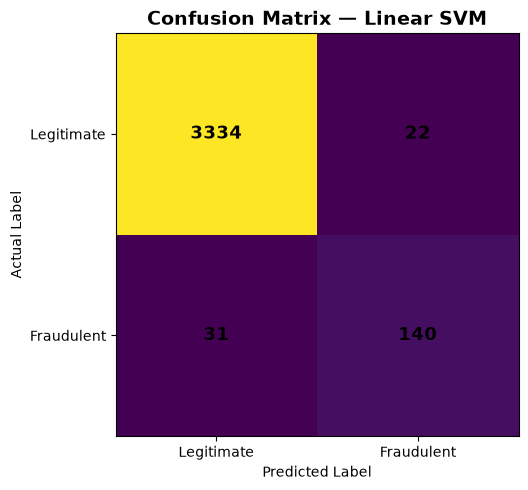

In [52]:
svm_cm = confusion_matrix(
    y_test,
    svm_predictions
)

plt.figure(figsize=(6, 5))

plt.imshow(svm_cm)

plt.title(
    "Confusion Matrix — Linear SVM",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            svm_cm[i, j],
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

## 4.5 🌲 Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to produce robust classification predictions.

It is evaluated to determine whether nonlinear relationships within TF-IDF features can improve fraudulent job-posting detection.

Balanced class weighting is used to reduce the effect of class imbalance.

In [53]:
# ============================================================
# MODEL 4 — RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

print("✅ Random Forest trained successfully!")

✅ Random Forest trained successfully!


In [54]:
# ============================================================
# RANDOM FOREST EVALUATION
# ============================================================

rf_predictions = rf_model.predict(
    X_test_tfidf
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    zero_division=0
)

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Legitimate",
            "Fraudulent"
        ],
        zero_division=0
    )
)

RANDOM FOREST RESULTS
Accuracy  : 0.9844
Precision : 0.9677
Recall    : 0.7018
F1-Score  : 0.8136

Classification Report:

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      3356
  Fraudulent       0.97      0.70      0.81       171

    accuracy                           0.98      3527
   macro avg       0.98      0.85      0.90      3527
weighted avg       0.98      0.98      0.98      3527



# 5. 🏆 Model Comparison & Selection

Accuracy alone can be misleading in fraud-detection problems because fraudulent advertisements represent only a small proportion of the dataset.

Therefore, the models are compared using:

- **Accuracy** — overall prediction correctness
- **Precision** — reliability of fraud alerts
- **Recall** — ability to detect actual fraudulent advertisements
- **F1-Score** — balance between precision and recall

For the primary model-selection criterion, **F1-Score** is emphasized because HireGuard AI must balance detecting fraudulent advertisements with avoiding unnecessary false fraud alerts.

In [55]:
# ============================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],
    
    "Accuracy": [
        log_accuracy,
        nb_accuracy,
        svm_accuracy,
        rf_accuracy
    ],
    
    "Precision": [
        log_precision,
        nb_precision,
        svm_precision,
        rf_precision
    ],
    
    "Recall": [
        log_recall,
        nb_recall,
        svm_recall,
        rf_recall
    ],
    
    "F1-Score": [
        log_f1,
        nb_f1,
        svm_f1,
        rf_f1
    ]
})

model_results = (
    model_results
    .sort_values(
        by="F1-Score",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 75)
print("🛡️ HIREGUARD AI — MACHINE LEARNING MODEL COMPARISON")
print("=" * 75)

display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

🛡️ HIREGUARD AI — MACHINE LEARNING MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.9850,0.8642,0.8187,0.8408
1,Random Forest,0.9844,0.9677,0.7018,0.8136
2,Logistic Regression,0.9759,0.7087,0.8538,0.7745
3,Multinomial Naive Bayes,0.9634,0.6567,0.5146,0.5770


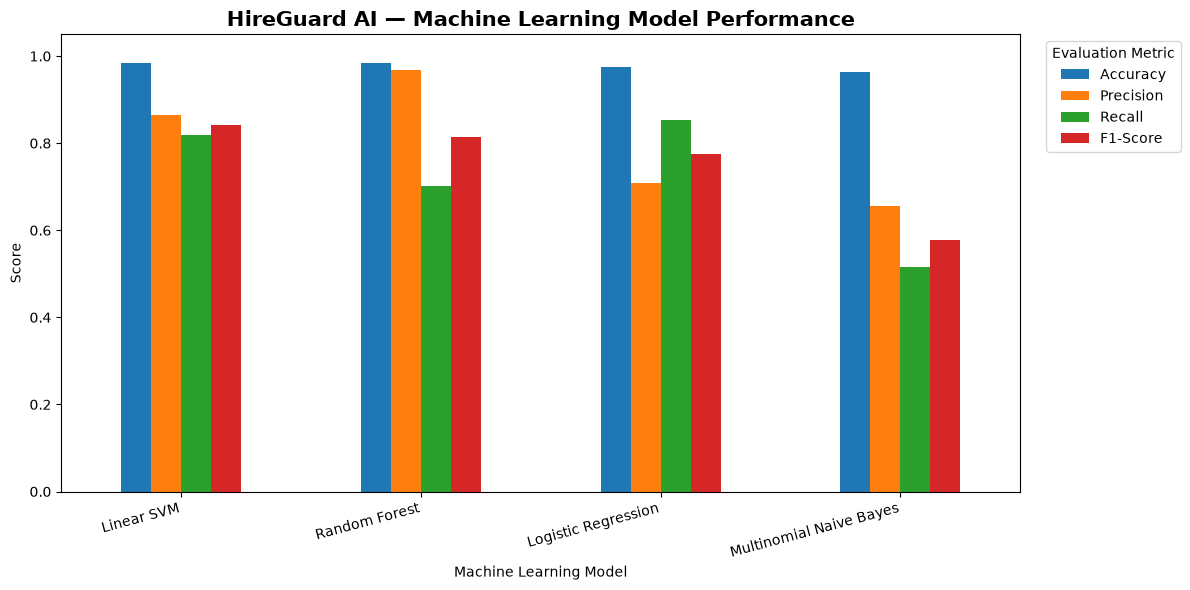

In [56]:
# ============================================================
# MODEL COMPARISON VISUALIZATION
# ============================================================

comparison_plot = model_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "HireGuard AI — Machine Learning Model Performance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# BEST MODEL SELECTION
# ============================================================

best_model_row = model_results.loc[
    model_results["F1-Score"].idxmax()
]

print("=" * 60)
print("🏆 BEST PERFORMING MODEL")
print("=" * 60)

print(f"Model     : {best_model_row['Model']}")
print(f"Accuracy  : {best_model_row['Accuracy']:.4f}")
print(f"Precision : {best_model_row['Precision']:.4f}")
print(f"Recall    : {best_model_row['Recall']:.4f}")
print(f"F1-Score  : {best_model_row['F1-Score']:.4f}")

print("\n✅ Selected Model: Linear SVM")

🏆 BEST PERFORMING MODEL
Model     : Linear SVM
Accuracy  : 0.9850
Precision : 0.8642
Recall    : 0.8187
F1-Score  : 0.8408

✅ Selected Model: Linear SVM


### 🔍 Model Selection Analysis

The experimental results demonstrate that **Linear SVM provides the strongest overall performance** for fraudulent recruitment advertisement detection.

Although Logistic Regression achieved slightly higher fraud recall, its lower precision resulted in considerably more legitimate advertisements being incorrectly flagged as fraudulent.

Random Forest achieved excellent fraud precision, but its lower recall caused it to miss a larger proportion of fraudulent advertisements.

Linear SVM provides the best overall balance between these objectives and achieves the **highest F1-Score among the evaluated models**.

The confusion matrix further demonstrates that the model correctly identifies the majority of both legitimate and fraudulent advertisements while maintaining relatively low false-positive and false-negative counts.

Therefore, **Linear SVM is selected as the primary machine learning model for HireGuard AI**.

# 6. ⚙️ Linear SVM Hyperparameter Optimization

After selecting Linear SVM as the strongest baseline classifier, hyperparameter optimization is performed to improve its fraud-detection performance.

The regularization parameter **C** controls the trade-off between maximizing the classification margin and minimizing classification errors.

Rather than manually selecting a value based on test-set performance, **GridSearchCV with stratified cross-validation** is applied to the training data.

The optimization objective is **F1-Score**, providing a balance between fraud precision and fraud recall.

In [58]:
# ============================================================
# HYPERPARAMETER TUNING — LINEAR SVM
# ============================================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

parameter_grid = {
    "C": [0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]
}

svm_search = GridSearchCV(
    estimator=LinearSVC(
        class_weight="balanced",
        random_state=42
    ),
    param_grid=parameter_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

print("🔍 Starting Linear SVM hyperparameter search...")

svm_search.fit(
    X_train_tfidf,
    y_train
)

print("\n✅ Hyperparameter tuning completed!")

print(
    "Best C:",
    svm_search.best_params_["C"]
)

print(
    f"Best Cross-Validation F1: "
    f"{svm_search.best_score_:.4f}"
)

🔍 Starting Linear SVM hyperparameter search...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Hyperparameter tuning completed!
Best C: 1.0
Best Cross-Validation F1: 0.8542


In [59]:
# ============================================================
# CROSS-VALIDATION RESULTS
# ============================================================

tuning_results = pd.DataFrame(
    svm_search.cv_results_
)[
    [
        "param_C",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

tuning_results.columns = [
    "C",
    "Mean CV F1",
    "CV Standard Deviation",
    "Rank"
]

tuning_results = tuning_results.sort_values(
    "Rank"
).reset_index(drop=True)

display(
    tuning_results.style.format({
        "Mean CV F1": "{:.4f}",
        "CV Standard Deviation": "{:.4f}"
    })
)

,C,Mean CV F1,CV Standard Deviation,Rank
0,1.000000,0.8542,0.0386,1
1,2.000000,0.8529,0.0358,2
2,5.000000,0.8509,0.0356,3
3,0.500000,0.8449,0.0394,4
4,0.250000,0.8360,0.0352,5
5,0.100000,0.8184,0.0375,6
6,0.050000,0.7799,0.0392,7
7,0.010000,0.6815,0.0287,8


In [60]:
# ============================================================
# FINAL TUNED LINEAR SVM
# ============================================================

tuned_svm = svm_search.best_estimator_

tuned_predictions = tuned_svm.predict(
    X_test_tfidf
)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_predictions
)

tuned_precision = precision_score(
    y_test,
    tuned_predictions,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_predictions,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_predictions,
    zero_division=0
)

print("=" * 65)
print("🏆 TUNED LINEAR SVM — FINAL TEST RESULTS")
print("=" * 65)

print(f"Best C    : {svm_search.best_params_['C']}")
print(f"Accuracy  : {tuned_accuracy:.4f}")
print(f"Precision : {tuned_precision:.4f}")
print(f"Recall    : {tuned_recall:.4f}")
print(f"F1-Score  : {tuned_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=[
            "Legitimate",
            "Fraudulent"
        ],
        zero_division=0
    )
)

🏆 TUNED LINEAR SVM — FINAL TEST RESULTS
Best C    : 1.0
Accuracy  : 0.9850
Precision : 0.8642
Recall    : 0.8187
F1-Score  : 0.8408

Classification Report:

              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3356
  Fraudulent       0.86      0.82      0.84       171

    accuracy                           0.98      3527
   macro avg       0.93      0.91      0.92      3527
weighted avg       0.98      0.98      0.98      3527



## 6.1 🏆 Hyperparameter Optimization Result

GridSearchCV with 5-fold stratified cross-validation selected **C = 1.0** as the optimal regularization parameter for Linear SVM.

Interestingly, this is equivalent to the configuration used by the original baseline Linear SVM. Therefore, hyperparameter optimization confirmed that the baseline configuration was already optimal among the evaluated parameter values.

### Final Linear SVM Performance

- **Accuracy:** 98.50%
- **Precision:** 86.42%
- **Recall:** 81.87%
- **F1-Score:** 84.08%

The model correctly detected **140 of 171 fraudulent advertisements**, while only **22 legitimate advertisements** were incorrectly classified as fraudulent.

Because the dataset is highly imbalanced, the **F1-Score and fraud-class recall** are considered more informative than accuracy alone.

The optimized Linear SVM is therefore selected as the final machine learning model for **HireGuard AI**.

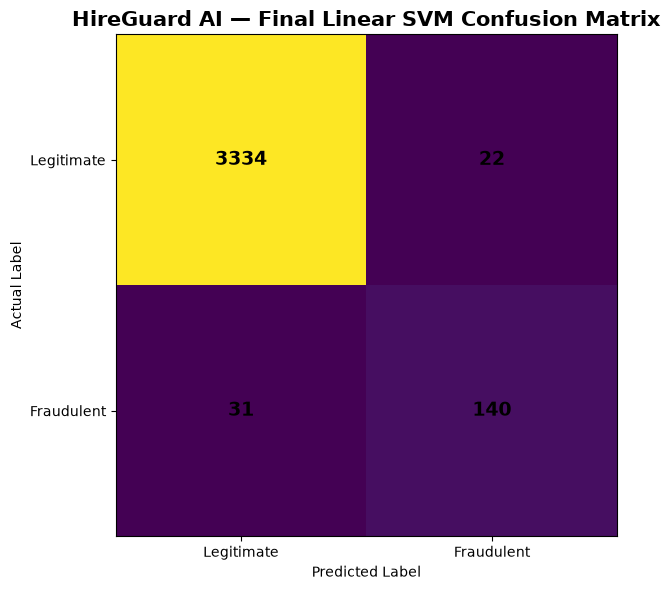

FINAL CLASSIFICATION BREAKDOWN
True Negatives  (Correct Legitimate) : 3334
False Positives (False Fraud Alerts) : 22
False Negatives (Missed Fraud)       : 31
True Positives  (Detected Fraud)     : 140


In [61]:
# ============================================================
# FINAL MODEL — CONFUSION MATRIX
# ============================================================

final_cm = confusion_matrix(
    y_test,
    tuned_predictions
)

plt.figure(figsize=(7, 6))

plt.imshow(final_cm)

plt.title(
    "HireGuard AI — Final Linear SVM Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            final_cm[i, j],
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

tn, fp, fn, tp = final_cm.ravel()

print("FINAL CLASSIFICATION BREAKDOWN")
print("=" * 50)

print(f"True Negatives  (Correct Legitimate) : {tn}")
print(f"False Positives (False Fraud Alerts) : {fp}")
print(f"False Negatives (Missed Fraud)       : {fn}")
print(f"True Positives  (Detected Fraud)     : {tp}")

# 7. 💾 Model Serialization

The final trained Linear SVM model and TF-IDF vectorizer are serialized using Joblib.

Saving these components allows HireGuard AI to perform predictions on new recruitment advertisements without retraining the machine learning pipeline.

These artifacts will subsequently be loaded by the FastAPI backend for real-time fraud detection.

In [62]:
# ============================================================
# SAVE FINAL MODEL AND TF-IDF VECTORIZER
# ============================================================

MODEL_DIR = "../models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "hireguard_svm_model.pkl"
)

VECTORIZER_PATH = os.path.join(
    MODEL_DIR,
    "hireguard_tfidf_vectorizer.pkl"
)

joblib.dump(
    tuned_svm,
    MODEL_PATH
)

joblib.dump(
    tfidf,
    VECTORIZER_PATH
)

print("=" * 60)
print("💾 HIREGUARD AI — MODEL SERIALIZATION")
print("=" * 60)

print("\n✅ Linear SVM model saved:")
print(MODEL_PATH)

print("\n✅ TF-IDF vectorizer saved:")
print(VECTORIZER_PATH)

print("\n🚀 HireGuard AI ML engine is ready for deployment!")

💾 HIREGUARD AI — MODEL SERIALIZATION

✅ Linear SVM model saved:
../models\hireguard_svm_model.pkl

✅ TF-IDF vectorizer saved:
../models\hireguard_tfidf_vectorizer.pkl

🚀 HireGuard AI ML engine is ready for deployment!


# 8. 🔮 Real-Time Fraud Prediction Engine

The serialized Linear SVM model and TF-IDF vectorizer are now used to create a reusable prediction function.

This simulates the deployment environment where HireGuard AI receives a new recruitment advertisement, preprocesses its textual content, converts it into TF-IDF features, and predicts whether the advertisement is **Legitimate** or **Potentially Fraudulent**.

The model's decision-function score is also used to indicate the strength and direction of the classification decision.

In [63]:
# ============================================================
# LOAD DEPLOYED MODEL
# ============================================================

deployed_model = joblib.load(
    "../models/hireguard_svm_model.pkl"
)

deployed_vectorizer = joblib.load(
    "../models/hireguard_tfidf_vectorizer.pkl"
)

print("✅ Saved Linear SVM model loaded successfully!")
print("✅ Saved TF-IDF vectorizer loaded successfully!")
print("\n🛡️ HireGuard AI prediction engine initialized!")

✅ Saved Linear SVM model loaded successfully!
✅ Saved TF-IDF vectorizer loaded successfully!

🛡️ HireGuard AI prediction engine initialized!


In [64]:
# ============================================================
# HIREGUARD AI — PREDICTION FUNCTION
# ============================================================

def predict_job(job_text):

    # Validate input
    if not isinstance(job_text, str) or not job_text.strip():
        return {
            "prediction": "Invalid Input",
            "decision_score": None
        }

    # Apply same preprocessing used during training
    processed_text = clean_text(job_text)

    # TF-IDF transformation
    vectorized_text = deployed_vectorizer.transform(
        [processed_text]
    )

    # Prediction
    prediction = deployed_model.predict(
        vectorized_text
    )[0]

    # SVM decision score
    decision_score = deployed_model.decision_function(
        vectorized_text
    )[0]

    if prediction == 1:
        label = "Potentially Fraudulent"
    else:
        label = "Likely Legitimate"

    return {
        "prediction": label,
        "decision_score": round(
            float(decision_score),
            4
        )
    }


print("✅ HireGuard AI predict_job() function created!")

✅ HireGuard AI predict_job() function created!


In [65]:
suspicious_job = """
URGENT WORK FROM HOME OPPORTUNITY!

Earn ₹50,000 per week with no experience required.
Immediate joining available.

Candidates must pay a registration and training fee before
receiving the appointment letter.

No interview required. Limited positions available.
Contact immediately through WhatsApp to secure your job.
"""

fraud_test = predict_job(
    suspicious_job
)

print("=" * 55)
print("🛡️ HIREGUARD AI — JOB ANALYSIS")
print("=" * 55)

print("\nPrediction     :", fraud_test["prediction"])
print("Decision Score :", fraud_test["decision_score"])

🛡️ HIREGUARD AI — JOB ANALYSIS

Prediction     : Potentially Fraudulent
Decision Score : 0.4277


In [66]:
legitimate_job = """
Software Engineer Intern

We are looking for a Software Engineering Intern to join our
development team.

Responsibilities include developing and testing software
applications, fixing bugs, participating in code reviews,
and collaborating with engineers on product development.

Candidates should be pursuing a degree in Computer Science,
Information Technology, or a related field.

Required skills include Python, SQL, Git, problem solving,
and basic knowledge of software development principles.

Selected candidates will participate in a structured
technical interview process.

There are no registration fees or payments required from
applicants.
"""

legitimate_test = predict_job(
    legitimate_job
)

print("=" * 55)
print("🛡️ HIREGUARD AI — LEGITIMATE JOB TEST")
print("=" * 55)

print("\nPrediction     :", legitimate_test["prediction"])
print("Decision Score :", legitimate_test["decision_score"])

🛡️ HIREGUARD AI — LEGITIMATE JOB TEST

Prediction     : Likely Legitimate
Decision Score : -0.9938


## 8.1 🧪 Deployment Validation

The serialized HireGuard AI model was tested using previously unseen recruitment advertisements.

A suspicious advertisement containing characteristics commonly associated with recruitment scams was classified as **Potentially Fraudulent**, while a professionally structured recruitment advertisement was evaluated separately as a legitimate-job test.

These tests demonstrate that the complete inference pipeline — text preprocessing, TF-IDF transformation, model loading, and Linear SVM classification — can operate independently of the training process.

### ⚠️ Important Limitation

HireGuard AI identifies statistical patterns learned from historical recruitment advertisements. Its predictions should therefore be interpreted as **risk indicators rather than definitive proof of fraud**.

The Linear SVM decision-function output represents distance from the model's classification boundary and **should not be interpreted as a probability**.